data/인구현황.csv 를 사용하세요

In [15]:
# 1. 지역별 총인구수 Top5

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns


data = pd.read_csv("../data/인구현황.csv")
data = data[data["행정기관"] != "전국"]
data.loc[:, ["행정기관", "총인구수"]].sort_values(by="총인구수", ascending=False).head(5)

,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


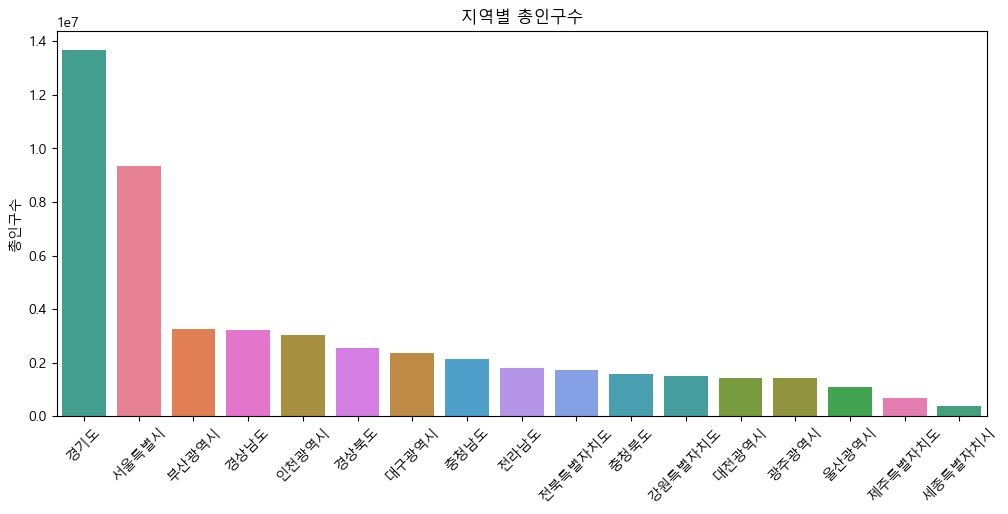

In [27]:
# 1-1. 지역별 총인구수 plot
font_path = 'C:\\Windows\\Fonts\\malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font_name)

figure, axes1 = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))

sns.barplot(data=data, x="행정기관", y="총인구수", ax=axes1, hue="행정기관",
            order=data.sort_values('총인구수', ascending=False)['행정기관'])

axes1.set_title('지역별 총인구수')
axes1.set_xlabel('')
axes1.set_ylabel('총인구수')
axes1.tick_params(axis='x', rotation=45)

In [30]:
# 2. 세대당 인구수 높은 지역 Top5

data.loc[:, ["행정기관", "세대당 인구"]].sort_values(by="세대당 인구", ascending=False).head(5).reset_index(drop=True)

,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


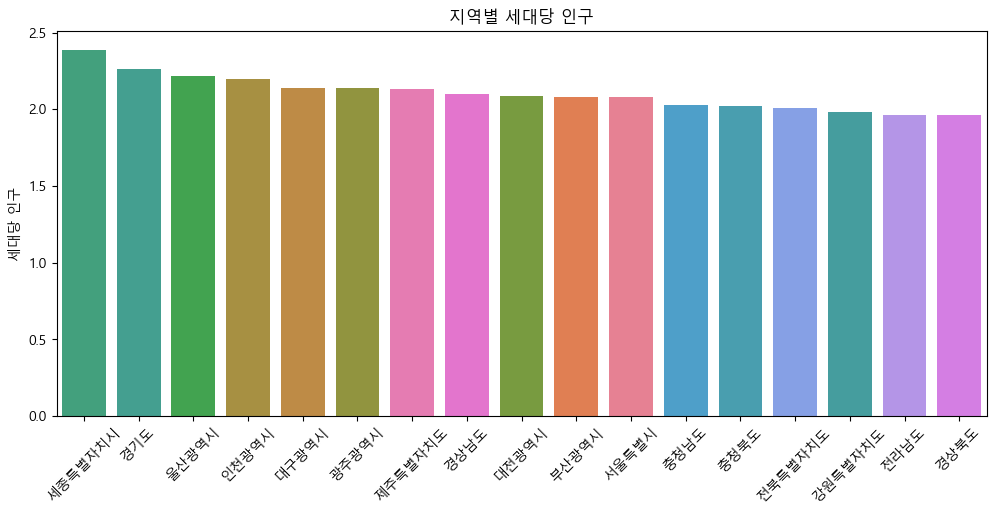

In [34]:
# 2-1. 지역별 세대당 인구 Plot

figure, axes1 = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))

sns.barplot(data=data, x="행정기관", y="세대당 인구", ax=axes1, hue="행정기관",
            order=data.sort_values('세대당 인구', ascending=False)['행정기관'])

axes1.set_title('지역별 세대당 인구')
axes1.set_xlabel('')
axes1.set_ylabel('세대당 인구')
axes1.tick_params(axis='x', rotation=45)

In [46]:
# 3. 남녀 비율 분석

data.loc[:, ["행정기관", "남여 비율"]].sort_values(by="남여 비율", ascending=False).reset_index(drop=True)

,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


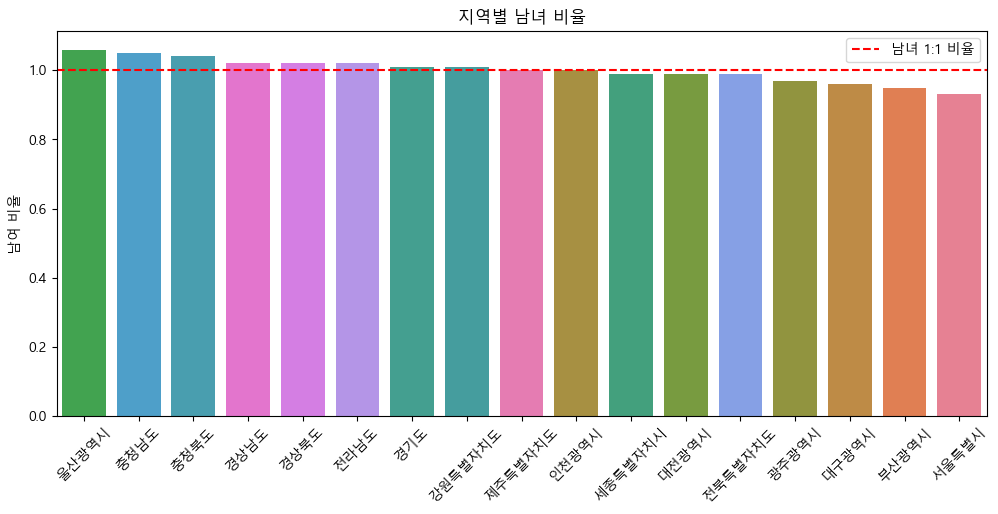

In [38]:
# 3-1. 남녀 비율 분석 Plot

figure, axes1 = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))

sns.barplot(data=data, x="행정기관", y="남여 비율", ax=axes1, hue="행정기관", order=data.sort_values('남여 비율', ascending=False)['행정기관'])

axes1.set_title('지역별 남녀 비율')
axes1.set_xlabel('')
axes1.set_ylabel('남여 비율')
axes1.tick_params(axis='x', rotation=45)
axes1.axhline(y=1, color='r', linestyle='--', label='남녀 1:1 비율')
axes1.legend()

In [47]:
# 4. 남자초과 / 여자초과 분석

data["남초여초"] = data["남여 비율"].apply(lambda x: "남초" if x > 1 else "여초" if x < 1 else "동일")
data.loc[:, ["행정기관", "남여 비율", "남초여초"]].reset_index(drop=True)

,행정기관,남여 비율,남초여초
0,서울특별시,0.93,여초
1,부산광역시,0.95,여초
2,대구광역시,0.96,여초
3,인천광역시,1.00,동일
4,광주광역시,0.97,여초
5,대전광역시,0.99,여초
6,울산광역시,1.06,남초
7,세종특별자치시,0.99,여초
8,경기도,1.01,남초
9,강원특별자치도,1.01,남초


In [ ]:
# 5. 세대당 인구 평균보다 높은 지역

data[data["세대당 인구"] > data["세대당 인구"].mean()].loc[:, ["행정기관", "세대당 인구"]].sort_values(by="세대당 인구", ascending=False).reset_index(drop=True)

,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


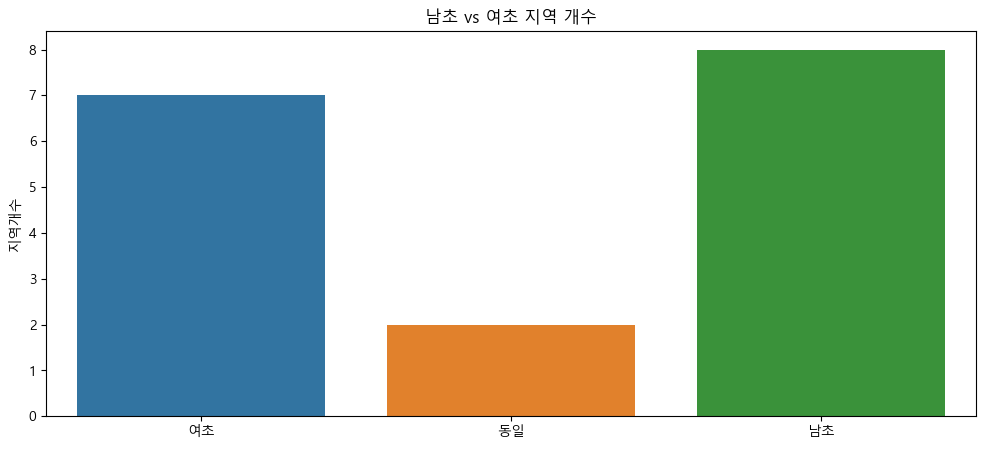

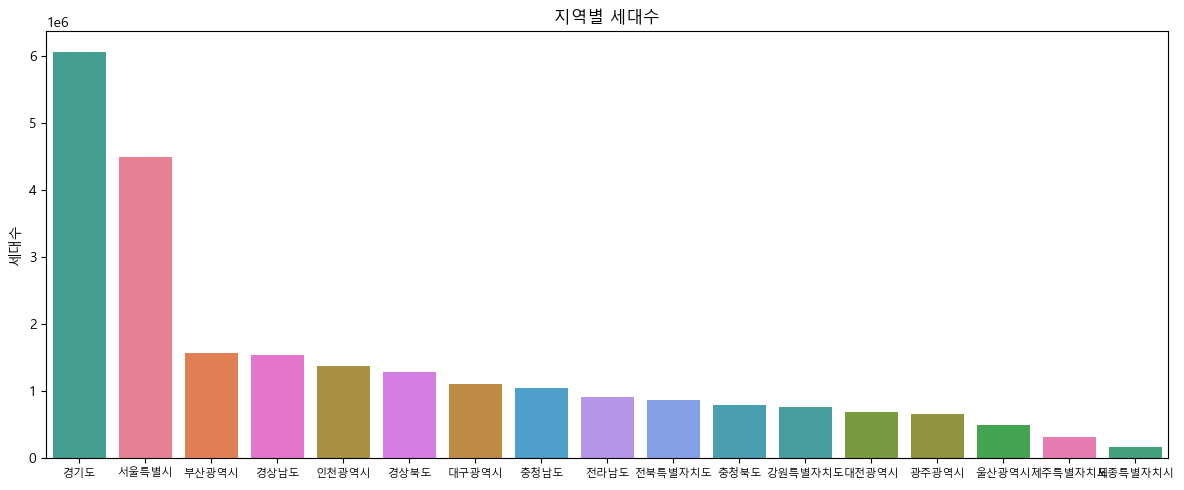

In [62]:
# 5-1.   남초 vs 여초 개수 Plot  ( seaborn의 countplot )
#         지역별 세대수 Plot ( seaborn의 barplot )

plt.figure(figsize=(12, 5))
sns.countplot(data=data, x="남초여초", hue="남초여초", order=["여초", "동일", "남초"])
plt.title("남초 vs 여초 지역 개수")
plt.xlabel("")
plt.ylabel("지역개수")

plt.figure(figsize=(12, 5))
sns.barplot(data=data, x="행정기관", y="세대수", hue="행정기관", order=data.sort_values('세대수', ascending=False)['행정기관'])
plt.title("지역별 세대수")
plt.xlabel("")
plt.ylabel("세대수")
plt.xticks(fontsize=8)
plt.tight_layout()

